## KV Caching: Accelerating Autoregressive Generation

### 1- Introduction


##### Objectives : 
- understand concretly how KV cache accelerate token generation for a given Transformer decoder model.
- Make benchmarks to measure the impact of having a KV cache.

##### Main ideas : 
- Without KV cache: for each iteration the transformer recalculate the attention for all the sequence for every new generated oken
- With KV cache :  the Keys and Values of tokens already calculated are memorized 

##### Plan : 
- will  be done 

##### Choosen model for exepriment : 
- GPT 2-small (124M param ) : a tiny small language model but with a simple and typical transformer decoder.

### 2- Imports

In [17]:
import torch
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Devide available : {device}")

dtype = torch.float32

Devide available : cuda


In [18]:
# loading tokenizer 
tokenizer=GPT2TokenizerFast.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2").to(device).to(dtype)


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2141.91it/s]


In [24]:
# deactivate the dropout for better benchmark results 
model.eval()

#model info
n_params = sum(p.numel() for p in model.parameters())
print(f"GPT-2 small : {n_params/1e6:.1f}M parameters ")
print(f"Layers (blocs Transformer) : {model.config.n_layer}")
print(f"Attention head for each layer : {model.config.n_head}")
print(f"Hidden dim : {model.config.n_embd}")

GPT-2 small : 124.4M parameters 
Layers (blocs Transformer) : 12
Attention head for each layer : 12
Hidden dim : 768


### 3- Theory of autoregressive generation

##### Issue : quadratic cost of token generation 

In a decode language model,  the decoder predict the token from the previous tokens. This generation is being done token by token.

- prompt -> predict token n°1
- prompt + token n°2  -> predict token n°2
- prompt + token 1 + token 2 - > predict token n°3 

....

In each step , the number of tokens in the input model is getting bigger generating some performance issue.

In a attention layer, every token "look back" all the previous tokens (as showed before). So for a sequence of n tokens represents n^2 interractions. If we calculate all for each token, generating T number of token cost :

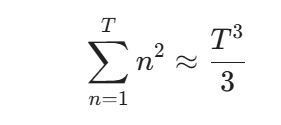

##### Solution : what the KV cache changes

When we add the token n , the keys/ values of the token 1 ... n-1 do not change (the attention is causale : mearning the past do not depend of the futur). So we can keep them in memory. 

Impact : At every step, we calculate the attention only for one new token using the cache => the cost of calcultation for each step O(n) => and the total cost is O(T^2) instead of O(T^3)

### 4- Implementing naive approche without KV cache

Here for each step , we give all the sequence to the model, we collect the logits of the last position , the model generate the next token and we do it again.

=> with this approach, we recalculate the K/V for all the past tokens for every step.


In [25]:
@torch.no_grad()  #  no need for inference (only training) reduce vram consumption
def generate_naive(prompt_ids, max_new_tokens):
    """ 
    Autoregressive generation SANS KV cache.
    For every step, we give THE ENTIRE sequence to the modele.
    """
    ids = prompt_ids.clone()  # (1, seq_len) stock la séquence pour intput

    for _ in range(max_new_tokens):
        # On passe TOUTE la séquence : Le modèle recalcule ttes les clés/valeurs de tous les tokens, à chaque itération.
        out = model(input_ids=ids, 
                    use_cache=False) # force the model to recalculate entirely

        # logits : (1, seq_len, vocab). On ne garde que la DERNIÈRE position, c'est elle qui prédit le token suivant.
        next_logits = out.logits[:, -1, :]

        #  take the token with the highest probabulity
        next_id = next_logits.argmax(dim=-1, keepdim=True)  # (1, 1)

        #  concatenate all of it
        ids = torch.cat([ids, next_id], dim=1)

    return ids

### 5- Implementing naive approache with KV cach

We use Hugging Face implementation use_cache=True, sending to the model the key /values already calculated (past_ket_values).

The mecanism changes: 
- Step 1: we give all the prompt and we collect the cache
- Next steps : We give only one token (the last one ) with the cache. The modele calculate the attention of this new token using the KV values in memory, then gives the cache.

=> the saving in compute is done because the model calculate only for the new token at each step.